# 1. Introduction

### 1.1 To get started, please write 5 examples of the application of ML methods in life. <br>What is the benefit of using machine learning methods in each of your examples?

1. Weather prediction. Benefit: you can plan your day activities according the prediction.
2. Face recognition. Benefit: you can pay/verify via your face.
3. Voice recognition. Benefit: you can manage smart devices via your voice.
4. Detect e-mail types. Benefit: you dont need to read spam, mass mailing or notifications from social media.
5. Diagnostics of diseases. Benefit: you can start treatment much earlier.
___
1. Прогноз погоды. Преимущество: планировать свои дела в соответствии с прогнозом.
2. Распознавание лиц. Преимущество: возможность платить/подтверждать с помощью лица.
3. Распознавание голоса. Преимущество: управление смарт-устройствами с помощью голоса.
4. Определение типов эл-почты. Преимущество: вам не нужно читать спам, массовые рассылки или уведомления из социальных сетей.
5. Диагностика заболеваний. Преимущество: вы можете начать лечение гораздо раньше.
___

### 1.2 Use the classification of tasks in the introduction to decide which class you can assign to the tasks from the table above and to the 5 examples you provided.


| Tasks | Type |
| --- | --- |
| 1. Predict house price | Supervised/Regression |
| 2. Predict whether a client returns a loan | Supervised/Classification|
| 3. Predict when a patient needs to take medicine | Supervised/Regression
| 4. Choose what medicine out of available a patient should take | Supervised/Classification
| 5. Choose segment of clients for a promo communication | Unsupervised/Clustering
| 6. Recognition of defective products on the production line (based on photo scans) | Supervised/Classification
| 7. Decide how to place products on a shelf in a store | Unsupervised/Association
| 8. Search sites for input text query | Supervised/Classification
| 9. Split customers of a store into segments to understand differences of their behavior | Unsupervised/Clustering
| 10. Detect anomaly in site traffic | Supervised/Classification |
| --- | --- |
| 11. Weather prediction |  Supervised/Classification |
| 12. Face recognition |  Supervised/Classification |
| 13. Voice recognition |  Supervised/Classification |
| 14. Detect e-mail types | Supervised/Classification |
| 15. Diagnostics of diseases | Supervised/Classification |

### 1.3 Think about what the difference is between multiclass and multilabel.


Multiclass classification is used in cases where each sample is assigned to one and only one label: a fruit can be either an apple or a pear or a banana, but not both at the same time.
Multilabel are a type of problem in which observations can belong to more than one class at a time. However, the classes are not mutually exclusive.

Мультиклассовая классификация используется в случаях, когда каждому образцу присваивается одна и только одна метка: фрукт может быть либо яблоком, либо грушей, либо бананом, но не обоими одновременно.
Классификацией по многим меткам — это тип проблемы, в которой наблюдения могут принадлежать более чем к одному классу одновременно. Однако классы не являются взаимоисключающими.

### 1.4 Is an example case with house prices from the theory a classification of a regression problem? <br> Is it possible to reduce the regression problem to classification?

Predict house price is a supervised regression problem. Yes it's possible to reduce the regression problem to classification by stratifying target. 

Прогнозирование цены дома — задача контролируемой регрессии. Да, можно свести задачу регрессии к классификации, стратифицировав цель.

# 2. Introduction to Data Analysis

### 2.1 Import the libraries pandas, numpy, sklearn, lightgbm, scipy, statsmodels, matplotlib, seaborn. Use pip install if necessary.

In [1]:
import warnings
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, accuracy_score
from sklearn.tree import DecisionTreeRegressor
import lightgbm as lgb
import scipy 
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings('ignore')
# pd.options.display.max_rows = 10

### 2.2 Load data from kaggle using pandas. You only need the table data, which is in train.json.

In [2]:
df = pd.read_json("data/train.json")
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


### 2.3 What is the size (the number of rows and columns) of your data?

In [3]:
df.shape

(49352, 15)

### 2.4 Print the list of columns. Which column is a target?

In [4]:
df.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

In [5]:
y = df['price']
y

4         2400
6         3800
9         3495
10        3000
15        2795
          ... 
124000    2800
124002    2395
124004    1850
124008    4195
124009    4280
Name: price, Length: 49352, dtype: int64

### 2.5 Make a quick analysis of the data: use the methods info(), describe(), corr(). Explain the results of the outputs.<br> Are there any empty columns?

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [7]:
df.describe().applymap(lambda x: f"{x:0.2f}")

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00,49352.00,49352.00,49352.00,49352.00,49352.00
mean,1.21,1.54,40.74,7024054.66,-73.96,3830.17
std,0.50,1.12,0.64,126274.61,1.18,22066.87
min,0.00,0.00,0.00,6811957.00,-118.27,43.00
25%,1.00,1.00,40.73,6915887.50,-73.99,2500.00
50%,1.00,1.00,40.75,7021070.50,-73.98,3150.00
75%,1.00,2.00,40.77,7128733.25,-73.95,4100.00
max,10.00,8.00,44.88,7753784.00,0.00,4490000.00


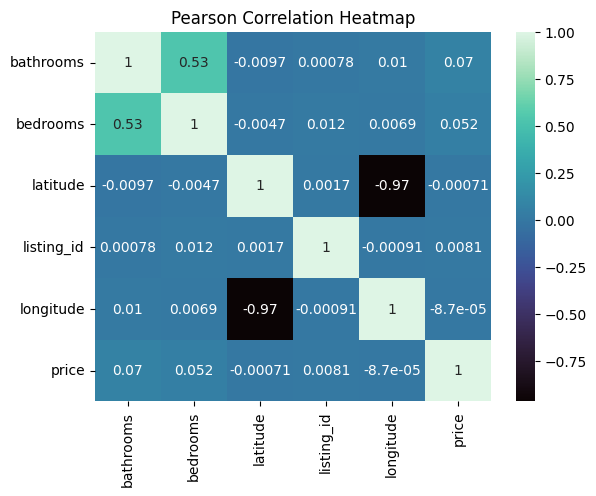

In [8]:
pearson_corr = df[df.describe().columns].corr(method="pearson")
sns.heatmap(data=pearson_corr, annot=True, cmap="mako")
plt.title("Pearson Correlation Heatmap")
plt.show()

In [9]:
# check missing values (empty columns)
any(df.isnull().sum())

False

### 2.6 We'll work with only 3 features: 'bathrooms', 'bedrooms', 'interest_level' and with the target column 'price'. Create a dataframe with only these columns.

In [10]:
df = df[['bathrooms', 'bedrooms', 'interest_level', 'price']] 
X = df[['bathrooms', 'bedrooms', 'interest_level']]
y = df['price']

# 3. Statistical Data Analysis

### 3.1 To get started with statistical data analysis, we recommend that you refresh your basic knowledge of statistics, such as Mean / Median / Mode / Variance / Standard Deviation. Also you are welcome to be free with distributions (Discrete uniform Distribution, Bernoulli Distribution, Binomial Distribution, Poisson Distribution, Normal Distribution, Exponential Distribution). Please make sure that you know the definitions of outliers, percentiles, confidential intervals. The article will be presented later

  - 1. Mean - The average value.<br> s = pd.Series([1, 2, 3, 3, 4]), s.mean() = 2.6
  - 2. Median - The mid point value<br>
  If odd - median_num = (n + 1) / 2, median = s[median_num]; s = pd.Series([1, 2, 3, 4, 5]) s.median() = 3,<br>
  If even -  median_num = n / 2, median = (s[median_num] + s[median_num + 1]) / 2;  s = pd.Series([1, 2, 3, 3]) s.median() = 2.5. 
  - 3. Mode - The most common value.<br> s = pd.Series([1, 2, 3, 3, 4]) s.mode() = 3
  - 4. Variance - The variance defines a measure of the spread or dispersion within a set of data.<br>
  There are two types: the population variance, usually denoted by $σ^2$ and the sample variance is usually denoted by $s^2$.
  <br>$Σ (xᵢ - x̄)² / (n - 1)$<br> s = pd.DataFrame({'age': [21, 25, 62, 43]}) s.var() = 352.92
  - 5. Standart Deviation - The standard deviation, often denoted by σ, is the positive square root of the variance.<br> 
  Data sets with a small standard deviation are tightly grouped around the mean, whereas a larger standard deviation indicates the data is more spread out.<br>
  $√Σ (xᵢ - x̄)² / (n - 1)$
  - 6. Normal Distribution (Gaussian distribution) - a probability distribution that is symmetric about the mean, showing that data near the mean<br> are more frequent in occurrence than data far from the mean. The normal distribution appears as a "bell curve" when graphed.<br>
  ![alt text](data/Standard_deviation_diagram_micro.svg.png)


### 3.2 Have a quick look at this article (https://towardsdatascience.com/how-to-compare-two-or-more-distributions-9b06ee4d30bf/). <br> Please pay attention to such aspects as distributions and histograms, boxplots, outliers, kernel density function.

### 3.3 Target analysis

#### 3.3.1 Plot a histogram to understand the distribution of the target. Is it all clear?

#### 3.3.2 The next step is boxplot(). What can you say about the target? Are there any outliers?

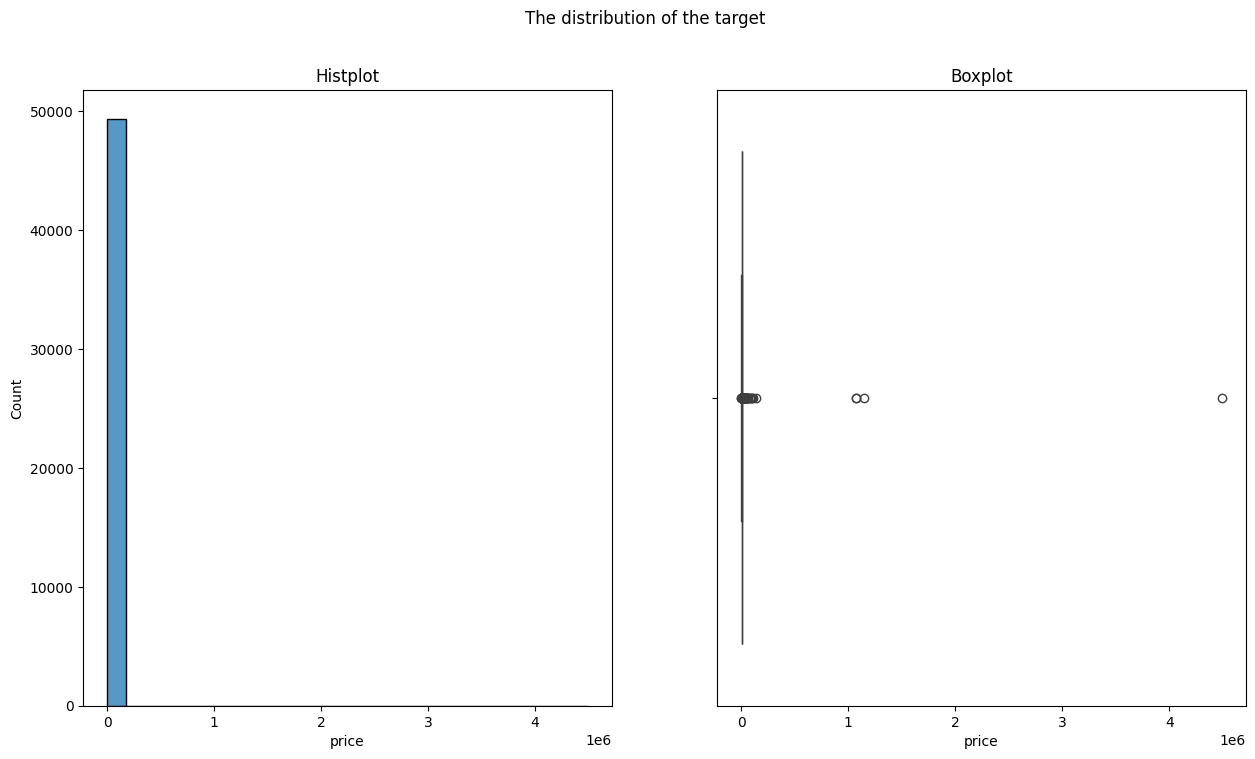

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,8))
sns.histplot(data=df, x='price', bins=25, ax = ax[0])
sns.boxplot(data=df, x='price', ax = ax[1])
ax[0].set_title("Histplot")
ax[1].set_title("Boxplot")
fig.suptitle("The distribution of the target")
fig.show()

#### 3.3.3 Drop the rows that are outside the 1 and 99 percentiles from the target column.

In [12]:
lower_limit = y.quantile(0.01)
upper_limit = y.quantile(0.99)
display(lower_limit, upper_limit)

outliers = y.loc[(y >= upper_limit) | (y <= lower_limit)]
display(outliers.head())

new_df = df.loc[(df['price'] < upper_limit) & (df['price'] > lower_limit)]

print("Before removing outliers num rows = ", len(y))
print("After removing outliers num rows = ", len(new_df['price']))
print("Outliers num = ", len(outliers), "\nCheck", len(outliers) == (len(y) - len(new_df['price'])))


np.float64(1475.0)

np.float64(13000.0)

140     13745
514     58020
706      1425
980      1350
1187    18000
Name: price, dtype: int64

Before removing outliers num rows =  49352
After removing outliers num rows =  48343
Outliers num =  1009 
Check True


#### 3.3.4 Plot another histogram for price. Explain the result.

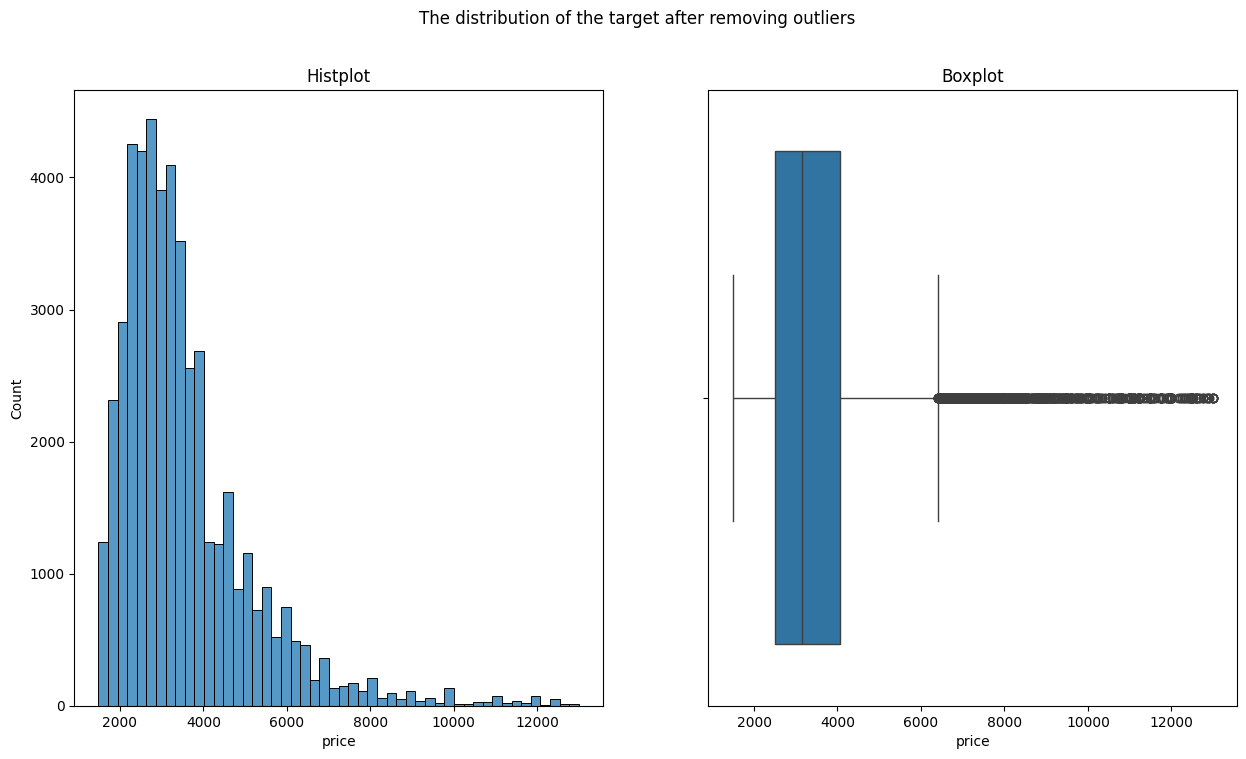

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,8))
sns.histplot(data=new_df, x='price', bins=50, ax = ax[0])
sns.boxplot(data=new_df, x='price', ax = ax[1])
ax[0].set_title("Histplot")
ax[1].set_title("Boxplot")
fig.suptitle("The distribution of the target after removing outliers")
fig.show()

### 3.4 Characteristics Analysis

#### 3.4.1 What is the type of column 'interest_level'?

In [14]:
type(new_df['interest_level'].iloc[0])

str

#### 3.4.2 Print the values in this column. How many entries does each value contain?

In [15]:
new_df['interest_level'].value_counts()

interest_level
low       33672
medium    11114
high       3557
Name: count, dtype: int64

#### 3.4.3 Encode these values. For example, you can replace each value with 0, 1, or 2.

In [16]:
values: dict = {'low': 0, 'medium': 1, 'high': 2}
new_df['interest_level'] = new_df['interest_level'].apply(lambda x: values[x])

new_df['interest_level'].value_counts()


interest_level
0    33672
1    11114
2     3557
Name: count, dtype: int64

#### 3.4.4 Plot histograms for the features 'bathrooms', 'bedrooms'. Are there any outliers?

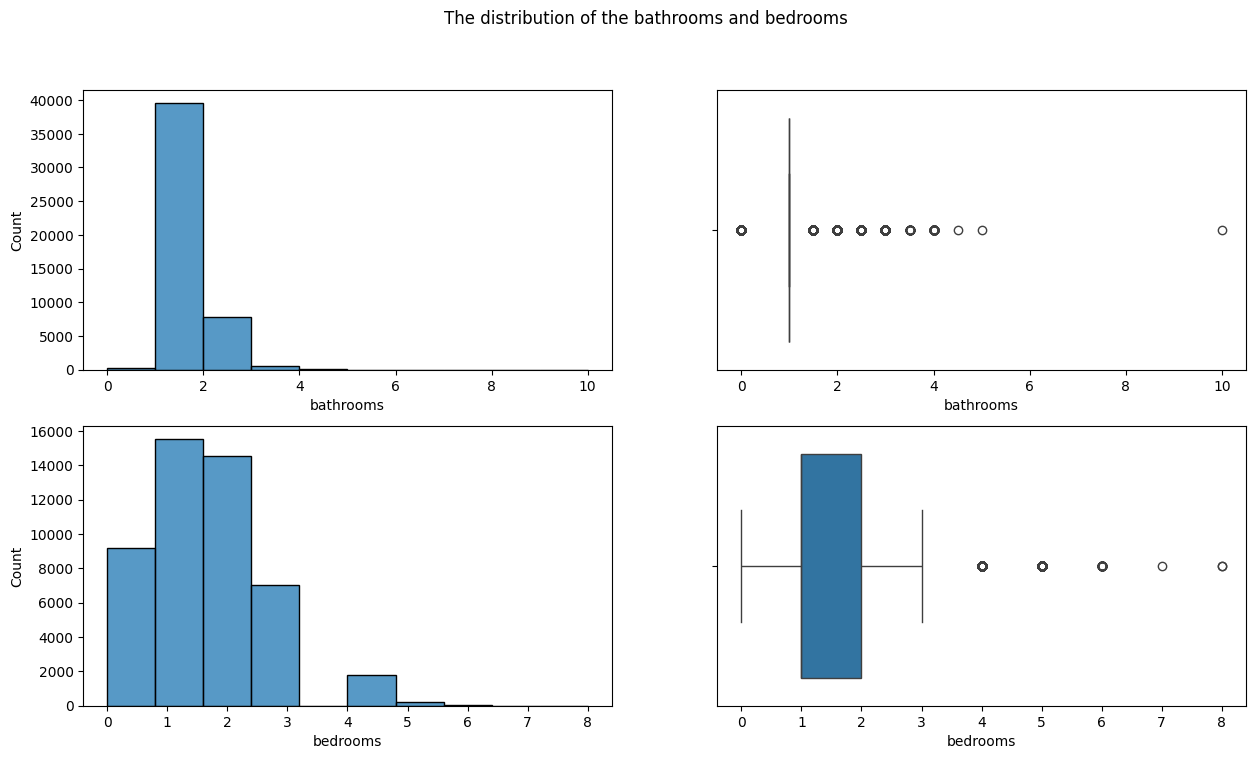

In [17]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15,8))
for num, x in enumerate(('bathrooms', 'bedrooms')):
    sns.histplot(data=new_df, x=x, bins=10, ax = ax[num][0])
    sns.boxplot(data=new_df, x=x, ax = ax[num][1])    

fig.suptitle("The distribution of the bathrooms and bedrooms")
fig.show()

### 3.5 Complex analysis

#### 3.5.1 Plot a correlation matrix to understand the correlation between features and target. Plot a heat map for the correlation matrix. Is there a correlation?

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517200,-0.062819,0.670808
bedrooms,0.517200,1.000000,0.051282,0.547310
interest_level,-0.062819,0.051282,1.000000,-0.199652
price,0.670808,0.547310,-0.199652,1.000000


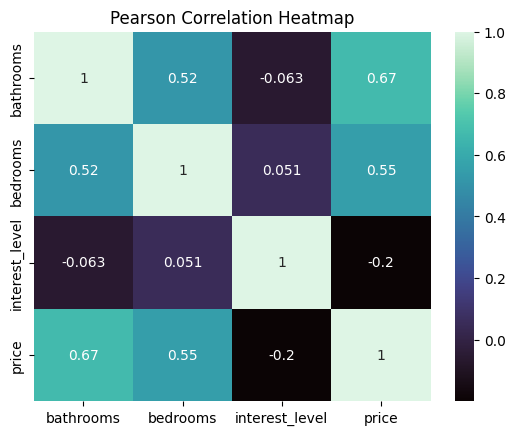

In [18]:
pearson_corr = new_df.corr(method="pearson")
display(pearson_corr)

sns.heatmap(data=pearson_corr, annot=True, cmap="mako")
plt.title("Pearson Correlation Heatmap")
plt.show()

#### 3.5.2 Plot a scatterplot to visualize the correlation between the features and the target. You should return 3 plots where the X-axis is the target and the Y-axis is a feature.

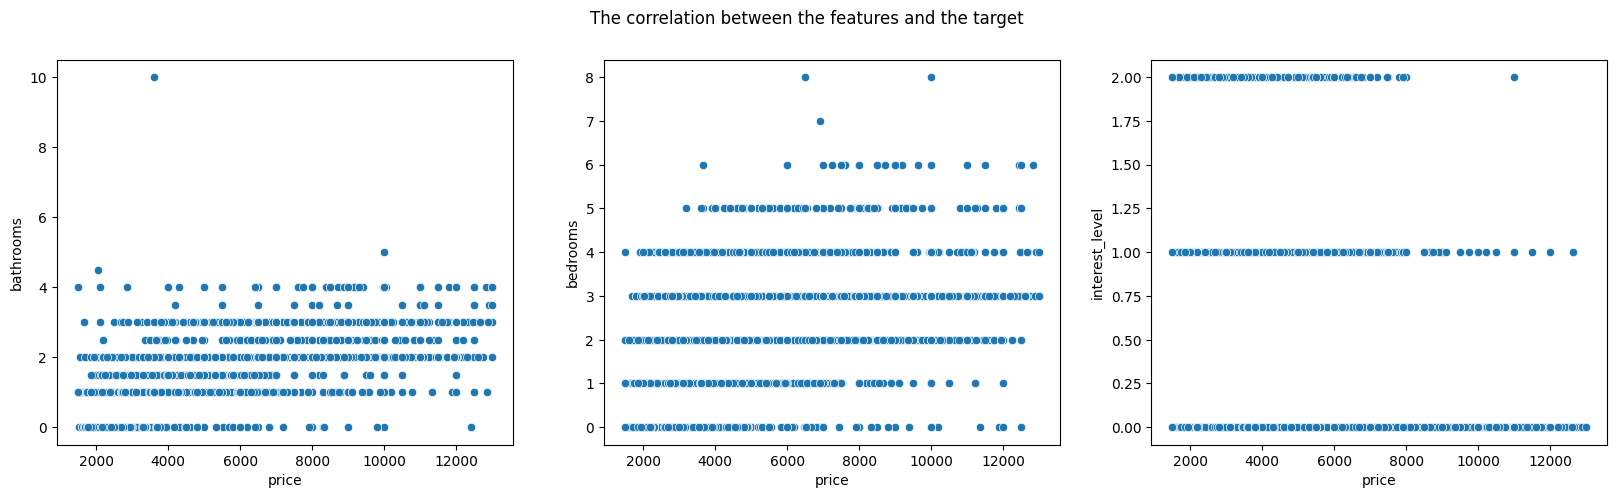

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5))
for num, y in enumerate(('bathrooms', 'bedrooms', 'interest_level')):
    sns.scatterplot(data=new_df, x='price', y=y, ax=ax[num])

fig.suptitle("The correlation between the features and the target")
fig.show()



# 4. Creating Features

### 4.1 This step is very broad. You can create as many features as you want. For example, you can add 3 new features that are squared: 'bathrooms_squared', 'bedrooms_squared', ''interest_level_squared'. Plot a correlation matrix with the new features. Are the new features more correlated with the target than the basic features?

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517200,-0.062819,0.670808,0.955906,0.548426,-0.058710
bedrooms,0.517200,1.000000,0.051282,0.547310,0.478497,0.928282,0.040125
interest_level,-0.062819,0.051282,1.000000,-0.199652,-0.067757,0.047048,0.943959
price,0.670808,0.547310,-0.199652,1.000000,0.646949,0.544612,-0.182283
bathrooms_squared,0.955906,0.478497,-0.067757,0.646949,1.000000,0.521951,-0.061563
bedrooms_squared,0.548426,0.928282,0.047048,0.544612,0.521951,1.000000,0.036408
interest_level_squared,-0.058710,0.040125,0.943959,-0.182283,-0.061563,0.036408,1.000000


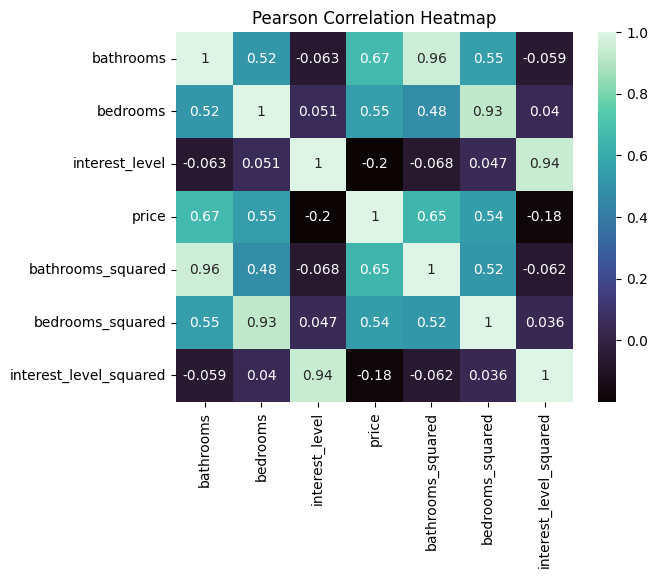

In [20]:
for x in ('bathrooms', 'bedrooms', 'interest_level'):
    new_df[f'{x}_squared'] = new_df[x].values**2
    
pearson_corr = new_df.corr(method="pearson")
display(pearson_corr)

sns.heatmap(data=pearson_corr, annot=True, cmap="mako")
plt.title("Pearson Correlation Heatmap")
plt.show()

Are the new features more correlated with the target than the basic features? 
Answer: no

### 4.2 To train the model here, we will not use your new features. Remember this example and use it in Lecture 2. To train the model, we will only consider the features 'bathrooms' and 'bedrooms'.

### 4.3 Read this Sklearn info about PolynomialFeatures (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html).

### 4.4 To use PolynomialFeatures, we first need to split the data into training and test samples. We have already done this for you, please read the training and test data.

In [21]:
df = new_df[['bathrooms', 'bedrooms', 'price']]
X = df[['bathrooms', 'bedrooms']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

### 4.5 Initialize PolynomialFeatures() with a degree of 10.

In [22]:
poly = PolynomialFeatures(10)

### 4.6 Apply PolynomialFeatures() to fit and transform your training and test data.

In [23]:
poly.fit_transform(X_train)
poly.fit_transform(X_test)

array([[1.000e+00, 1.000e+00, 1.000e+00, ..., 1.000e+00, 1.000e+00,
        1.000e+00],
       [1.000e+00, 2.000e+00, 2.000e+00, ..., 1.024e+03, 1.024e+03,
        1.024e+03],
       [1.000e+00, 1.000e+00, 1.000e+00, ..., 1.000e+00, 1.000e+00,
        1.000e+00],
       ...,
       [1.000e+00, 1.000e+00, 1.000e+00, ..., 1.000e+00, 1.000e+00,
        1.000e+00],
       [1.000e+00, 1.000e+00, 2.000e+00, ..., 2.560e+02, 5.120e+02,
        1.024e+03],
       [1.000e+00, 1.000e+00, 1.000e+00, ..., 1.000e+00, 1.000e+00,
        1.000e+00]], shape=(9669, 66))

# 5. Now you need to train 3 models: linear regression, decision tree and naive model. We will use them as black boxes without deep understanding.


### 5.1 Results table

#### 5.1.1 Create two empty Pandas DataFrames with columns 'model', 'train', 'test'. Let's call the first one result_MAE and the second one result_RMSE. We will fill these tables with the results of the models.

In [24]:
result_MAE = pd.DataFrame(columns=('model', 'train', 'test'))
result_RMSE = pd.DataFrame(columns=('model', 'train', 'test'))

### 5.2 Linear Regression

#### 5.2.1 Initialize linear regression from sklearn with no parameters.

In [25]:
model = LinearRegression()

#### 5.2.2 Fit your model and make predictions on training and test features. Save it as new columns in data.

In [26]:
model.fit(X_train, y_train)
test_y_pred = model.predict(X_test)
train_y_pred = model.predict(X_train)

#### 5.2.3 Compute MAE (Mean Absolute Error) on training and test targets.

In [27]:
test_MAE = mean_absolute_error(y_test, test_y_pred)
train_MAE = mean_absolute_error(y_train, train_y_pred)


#### 5.2.4 Calculate RMSE (Root Mean Square Error) on training and test objectives.

In [28]:
test_RMSE = root_mean_squared_error(y_test, test_y_pred)
train_RMSE = root_mean_squared_error(y_train, train_y_pred)

#### 5.2.5 Insert your metrics into tables result_MAE and result_RMSE with model name 'linear_regression'.

In [29]:
result_MAE.loc[0] = ['linear_regression', train_MAE, test_MAE]
display(result_MAE)
result_RMSE.loc[0] = ['linear_regression', train_RMSE, test_RMSE]
result_RMSE

,model,train,test
0,linear_regression,780.407567,787.031329


,model,train,test
0,linear_regression,1115.214468,1118.233792


### 5.3 Decision Tree

#### 5.3.1 Initialize decision tree regressor from sklearn with fixed random_state=21.

In [30]:
model = DecisionTreeRegressor(random_state=21)

#### 5.3.2 Fit it to train features and train target and make prediction on train and test features. Save it as a new column in data.

In [31]:
model.fit(X_train, y_train)
test_y_pred = model.predict(X_test)
train_y_pred = model.predict(X_train)

#### 5.3.3 Compute MAE (Mean Absolute Error) on train and test targets.

In [32]:
test_MAE = mean_absolute_error(y_test, test_y_pred)
train_MAE = mean_absolute_error(y_train, train_y_pred)

#### 5.3.4 Compute RMSE (Root Mean Square Error) on train and test targets.

In [33]:
test_RMSE = root_mean_squared_error(y_test, test_y_pred)
train_RMSE = root_mean_squared_error(y_train, train_y_pred)

#### 5.3.5 Insert your metrics into tables result_MAE and result_RMSE with model name 'decision_tree'.

In [34]:
result_MAE.loc[1] = ['decision_tree', train_MAE, test_MAE]
display(result_MAE)
result_RMSE.loc[1] = ['decision_treen', train_RMSE, test_RMSE]
result_RMSE

,model,train,test
0,linear_regression,780.407567,787.031329
1,decision_tree,752.669057,760.319019


,model,train,test
0,linear_regression,1115.214468,1118.233792
1,decision_treen,1070.262495,1074.556632


### 5.4 Naive Models

#### 5.4.1 Calculate the mean and median of 'price' on the training and test data and create a column with these values.

In [35]:
new_y_train = y_train.to_frame()
new_y_train['mean'] = y_train.mean()
new_y_train['median'] = y_train.median()

new_y_test = y_test.to_frame()
new_y_test['mean'] = y_test.mean()
new_y_test['median'] = y_test.median()


#### 5.4.2 Calculate the MAE on the training and test targets between your target and the calculated mean and median.

In [36]:
mean_test_MAE = mean_absolute_error(y_test, new_y_test['mean'])
mean_train_MAE = mean_absolute_error(y_train, new_y_train['mean'])

median_test_MAE = mean_absolute_error(y_test, new_y_test['median'])
median_train_MAE = mean_absolute_error(y_train, new_y_train['median'])

#### 5.4.3 Calculate the RMSE on the training and test targets between your target and the calculated mean and median.

In [37]:
mean_test_RMSE = root_mean_squared_error(y_test, new_y_test['mean'])
mean_train_RMSE = root_mean_squared_error(y_train, new_y_train['mean'])

median_test_RMSE = root_mean_squared_error(y_test, new_y_test['median'])
median_train_RMSE = root_mean_squared_error(y_train, new_y_train['median'])

#### 5.4.4 Insert your metrics into tables result_MAE and result_RMSE with model names 'naive_mean' and 'naive_median'.

In [38]:
result_MAE.loc[2] = ['mean', mean_train_MAE, mean_test_MAE]
result_MAE.loc[3] = ['median', median_train_MAE, median_test_MAE]

result_RMSE.loc[2] = ['mean', mean_train_RMSE, mean_test_RMSE]
result_RMSE.loc[3] = ['median', median_train_RMSE, median_test_RMSE]

### 5.5 Compare the results

#### 5.5.1 Print your final result_MAE and result_RMSE tables.

In [39]:
result_MAE

,model,train,test
0,linear_regression,780.407567,787.031329
1,decision_tree,752.669057,760.319019
2,mean,1131.815443,1144.533690
3,median,1079.734162,1092.166408


In [40]:
result_RMSE

,model,train,test
0,linear_regression,1115.214468,1118.233792
1,decision_treen,1070.262495,1074.556632
2,mean,1580.460676,1606.034024
3,median,1626.873056,1651.661962


#### 5.5.2 Which is the best model?

The best model is decision tree (the smallest errors values)

### 5.6 Additional

#### 5.6.1 You can practice with all the data in your starting dataset. Use and generate all the features you want.